# Do law professors teach what they believe?

This notebook uses a redacted row-level survey data file with all non-sensitive survey variables retained. It excludes survey-platform metadata, response IDs, institution/school fields, IPEDS identifiers, timestamps, open-ended/specify responses, and other fields treated as potentially identifying.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import pandas as pd
import seaborn as sns

sns.set_theme(style="white", context="notebook")
plt.rcParams.update({
    "figure.dpi": 130,
    "font.family": "DejaVu Sans",
    "axes.titlesize": 14,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})

DATA_DIR = Path("data")
REDACTED_RAW_PATH = DATA_DIR / "law_faculty_survey_redacted_raw.csv"
CODEBOOK_PATH = DATA_DIR / "law_faculty_survey_codebook.csv"


In [2]:
raw_survey = pd.read_csv(REDACTED_RAW_PATH)
codebook = pd.read_csv(CODEBOOK_PATH)

print(f"Redacted row-level survey data: {REDACTED_RAW_PATH}")
print(f"Codebook: {CODEBOOK_PATH}")
raw_survey.head()


Redacted row-level survey data: data/law_faculty_survey_redacted_raw.csv
Codebook: data/law_faculty_survey_codebook.csv


,selfcensor,adminclear,admincontr,worryrep,worryjob,fa_insult,fa_offen,fa_teach,fa_emot,fa_unrest,...,Degree_4,Degree_5,Gender,Race,Ideo,ideobin,Party,age_5cat,Religion,Religion2
0,Occasionally,Somewhat clear,Not very likely,Not too worried,Not too worried,Some protection,Complete protection,Complete protection,Don’t know / uncertain,Don’t know / uncertain,...,NaN,NaN,Male,White or Caucasian,Liberal,liberal,Strong Democrat,35-44,Agnostic,NaN
1,Rarely,Somewhat clear,Not very likely,Not too worried,Not too worried,Minimal protection,Some protection,Complete protection,Some protection,Some protection,...,NaN,NaN,Male,White or Caucasian,Liberal,liberal,Strong Democrat,65+,Nothing in Particular,NaN
2,Occasionally,Not very clear,Somewhat likely,Somewhat worried,Very worried,Complete protection,Complete protection,Complete protection,Some protection,Complete protection,...,NaN,NaN,Female,White or Caucasian,"Moderate, middle-of-the-road",moderate,Lean Democrat,55-64,Jewish,NaN
3,Never,Very clear,NaN,Not at all worried,Not at all worried,Some protection,Complete protection,Complete protection,Some protection,Complete protection,...,NaN,NaN,Male,White or Caucasian,Conservative,conservative,Lean Republican,65+,Mainline Protestant,NaN
4,"Fairly often, a couple times a week",Somewhat clear,Somewhat likely,Very worried,Somewhat worried,Complete protection,Complete protection,Complete protection,Complete protection,Complete protection,...,NaN,NaN,Male,White or Caucasian,Conservative,conservative,Strong Republican,65+,Mainline Protestant,NaN


In [3]:
def build_heatmap_cells(raw_data, codebook):
    judgeview_order = codebook.loc[codebook["variable"].eq("judgeview")].sort_values("value_code")["value_label"].tolist()
    judgeteach_order = codebook.loc[codebook["variable"].eq("judgeteach")].sort_values("value_code")["value_label"].tolist()
    spectrum_order = [label for label in judgeview_order if "politically motivated" in label or "politically neutral" in label]
    spectrum_order = [label for label in spectrum_order if "Don" not in label and "unsure" not in label and "characterize" not in label]

    groups = {
        "Overall": raw_data,
        "Male": raw_data[raw_data["Gender"].eq("Male")],
        "Female": raw_data[raw_data["Gender"].eq("Female")],
    }
    rows = []
    for group_name, group_df in groups.items():
        for spectrum_name, row_order, col_order in [
            ("all_responses", judgeview_order, judgeteach_order),
            ("spectrum_only", spectrum_order, spectrum_order),
        ]:
            sub = group_df.dropna(subset=["judgeview", "judgeteach"]).copy()
            sub = sub[(sub["judgeview"].ne("")) & (sub["judgeteach"].ne(""))]
            if spectrum_name == "spectrum_only":
                sub = sub[sub["judgeview"].isin(spectrum_order) & sub["judgeteach"].isin(spectrum_order)]
            group_n = len(sub)
            counts = pd.crosstab(sub["judgeview"], sub["judgeteach"]).reindex(index=row_order, columns=col_order, fill_value=0)
            row_totals = counts.sum(axis=1)
            pct = counts.div(row_totals.replace(0, pd.NA), axis=0) * 100
            for row_idx, judgeview in enumerate(row_order, start=1):
                for col_idx, judgeteach in enumerate(col_order, start=1):
                    rows.append({
                        "group": group_name,
                        "spectrum": spectrum_name,
                        "judgeview": judgeview,
                        "judgeteach": judgeteach,
                        "n": int(counts.loc[judgeview, judgeteach]) if judgeview in counts.index and judgeteach in counts.columns else 0,
                        "pct": pct.loc[judgeview, judgeteach] if judgeview in pct.index and judgeteach in pct.columns else pd.NA,
                        "row_total": int(row_totals.loc[judgeview]) if judgeview in row_totals.index else 0,
                        "group_n": group_n,
                        "row_order": row_idx,
                        "col_order": col_idx,
                    })
    return pd.DataFrame(rows)

heatmap_cells = build_heatmap_cells(raw_survey, codebook)
heatmap_cells.head()


,group,spectrum,judgeview,judgeteach,n,pct,row_total,group_n,row_order,col_order
0,Overall,all_responses,Judges are entirely politically motivated.,Judges are entirely politically motivated.,12,57.142857,21,1649,1,1
1,Overall,all_responses,Judges are entirely politically motivated.,Judges are mostly politically motivated.,4,19.047619,21,1649,1,2
2,Overall,all_responses,Judges are entirely politically motivated.,Judges are a mix of politically motivated and ...,1,4.761905,21,1649,1,3
3,Overall,all_responses,Judges are entirely politically motivated.,Judges are mostly politically neutral.,0,0.0,21,1649,1,4
4,Overall,all_responses,Judges are entirely politically motivated.,Judges are completely politically neutral.,0,0.0,21,1649,1,5


In [4]:
summary = (
    heatmap_cells[["group", "spectrum", "group_n"]]
    .drop_duplicates()
    .sort_values(["spectrum", "group"])
    .reset_index(drop=True)
)
summary


,group,spectrum,group_n
0,Female,all_responses,541
1,Male,all_responses,977
2,Overall,all_responses,1649
3,Female,spectrum_only,387
4,Male,spectrum_only,787
5,Overall,spectrum_only,1266


In [5]:
codebook


,variable,variable_label,value_code,value_label
0,selfcensor,"At your law school, how often, if at all, have...",1,Never
1,selfcensor,"At your law school, how often, if at all, have...",2,Rarely
2,selfcensor,"At your law school, how often, if at all, have...",3,Occasionally
3,selfcensor,"At your law school, how often, if at all, have...",4,"Fairly often, a couple times a week"
4,selfcensor,"At your law school, how often, if at all, have...",5,"Very often, nearly every day"
...,...,...,...,...
387,Religion2,Do you belong to any one of these churches or ...,10,Holiness
388,Religion2,Do you belong to any one of these churches or ...,11,Reformed
389,Religion2,Do you belong to any one of these churches or ...,12,Adventist
390,Religion2,Do you belong to any one of these churches or ...,13,Jehovah’s Witness


In [6]:
FULL_ROW_ORDER = codebook.loc[codebook["variable"].eq("judgeview")].sort_values("value_code")["value_label"].tolist()
FULL_COL_ORDER = codebook.loc[codebook["variable"].eq("judgeteach")].sort_values("value_code")["value_label"].tolist()
SPECTRUM_ORDER = [
    label for label in FULL_ROW_ORDER
    if "politically motivated" in label or "politically neutral" in label
]
SPECTRUM_ORDER = [
    label for label in SPECTRUM_ORDER
    if "Don" not in label and "unsure" not in label and "characterize" not in label
]

DISPLAY_LABELS = {
    "Judges are entirely politically motivated.": "Entirely\npolitical",
    "Judges are mostly politically motivated.": "Mostly\npolitical",
    "Judges are a mix of politically motivated and politically neutral.": "Mixed political\nand neutral",
    "Judges are mostly politically neutral.": "Mostly\nneutral",
    "Judges are completely politically neutral.": "Completely\nneutral",
    "Don’t know / unsure.": "Don’t know\n/ unsure",
    "I don’t characterize judges’ decision making as either politically motivated or politically neutral.": "Do not\ncharacterize",
}

GROUP_LABELS = {
    "Overall": "All faculty",
    "Male": "Men",
    "Female": "Women",
}

SPECTRUM_LABELS = {
    "all_responses": "All responses",
    "spectrum_only": "Political-to-neutral scale only",
}

CHART_TITLE = "Do law professors teach what they believe?"
CREDIT_TEXT = "Chart: Chapin Lenthall-Cleary\nSource: FIRE's 2026 Law Faculty Survey"


def heatmap_matrices(data, group, spectrum):
    sub = data[data["group"].eq(group) & data["spectrum"].eq(spectrum)].copy()
    if sub.empty:
        raise ValueError(f"No rows for group={group}, spectrum={spectrum}")

    row_order = SPECTRUM_ORDER if spectrum == "spectrum_only" else FULL_ROW_ORDER
    col_order = SPECTRUM_ORDER if spectrum == "spectrum_only" else FULL_COL_ORDER

    pct = (
        sub.pivot_table(index="judgeview", columns="judgeteach", values="pct", aggfunc="sum")
        .reindex(index=row_order, columns=col_order)
        .astype(float)
    )
    counts = (
        sub.pivot_table(index="judgeview", columns="judgeteach", values="n", aggfunc="sum")
        .reindex(index=row_order, columns=col_order)
    )

    labels = pct.copy().astype(object)
    for row in pct.index:
        for col in pct.columns:
            if pd.isna(pct.loc[row, col]):
                labels.loc[row, col] = ""
            else:
                value = pct.loc[row, col]
                count = int(counts.loc[row, col])
                pct_label = "<1%" if 0 < value < 1 else f"{value:.0f}%"
                labels.loc[row, col] = f"{pct_label}\nn={count:,}"

    return pct, labels, int(sub["group_n"].iloc[0])


def plot_judges_heatmap(data, group, spectrum):
    pct, labels, group_n = heatmap_matrices(data, group, spectrum)
    mask = pct.isna()
    n_rows, n_cols = pct.shape

    fig_width = 8.9 if spectrum == "all_responses" else 7.9
    fig_height = 5.7 if spectrum == "all_responses" else 5.15
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))

    cmap = sns.color_palette("Blues", as_cmap=True)
    sns.heatmap(
        pct,
        ax=ax,
        mask=mask,
        cmap=cmap,
        vmin=0,
        vmax=100,
        linewidths=0.8,
        linecolor="#ffffff",
        annot=labels,
        fmt="",
        annot_kws={"fontsize": 8.5, "linespacing": 1.15},
        cbar_kws={"label": "Percent of row", "shrink": 0.74, "pad": 0.04},
    )

    diagonal_cells = min(5, n_rows, n_cols)
    for idx in range(diagonal_cells):
        if not mask.iloc[idx, idx]:
            ax.add_patch(Rectangle((idx, idx), 1, 1, fill=False, edgecolor="#1f2937", lw=1.8))

    subtitle = f"{GROUP_LABELS[group]} | {SPECTRUM_LABELS[spectrum]} | N={group_n:,} | Each row sums to 100%"
    title_text = CHART_TITLE if group == "Overall" and spectrum == "all_responses" else f"{CHART_TITLE}\n{subtitle}"
    ax.set_title(title_text, loc="left", pad=14, fontsize=13, fontweight="bold")

    ax.set_xlabel("How faculty characterize judges in class", labelpad=12)
    ax.set_ylabel("How faculty personally view judges", labelpad=12)
    ax.set_xticklabels([DISPLAY_LABELS.get(t.get_text(), t.get_text()) for t in ax.get_xticklabels()], rotation=0, ha="center")
    ax.set_yticklabels([DISPLAY_LABELS.get(t.get_text(), t.get_text()) for t in ax.get_yticklabels()], rotation=0, va="center")
    ax.tick_params(axis="both", length=0)

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.8)
        spine.set_edgecolor("#d1d5db")

    fig.text(
        0.86,
        0.045,
        CREDIT_TEXT,
        ha="right",
        va="bottom",
        fontsize=8.2,
        color="#4b5563",
    )
    fig.tight_layout(rect=[0, 0.075, 1, 1])
    plt.show()


## Original core heatmaps

Includes all valid `judgeview` and `judgeteach` responses.


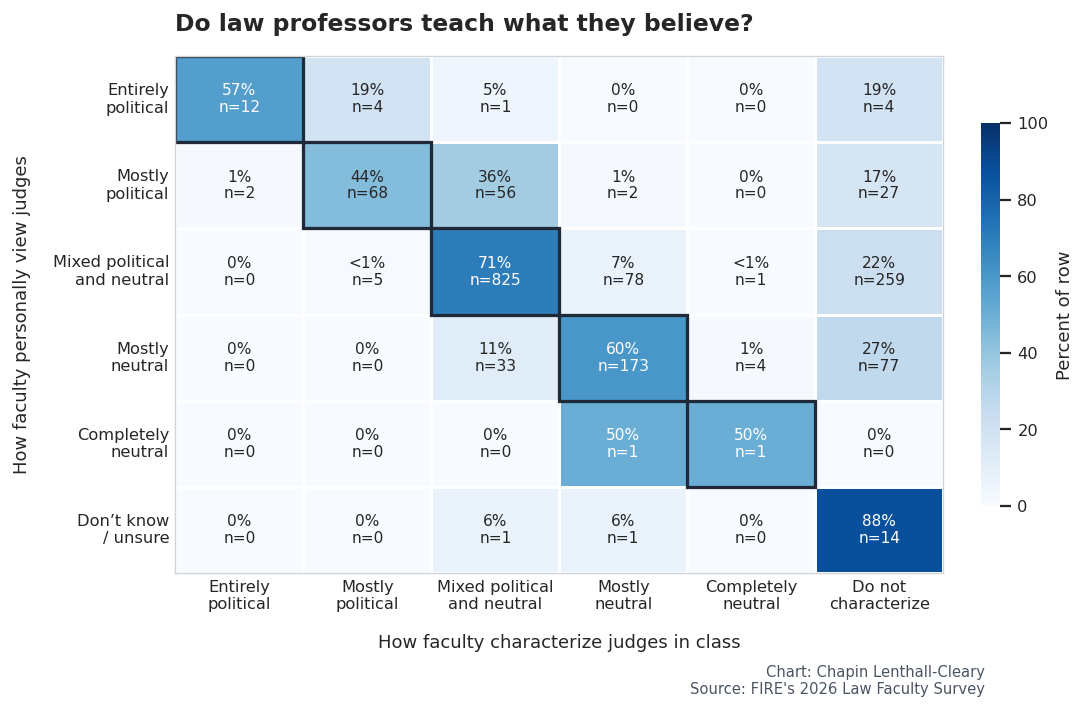

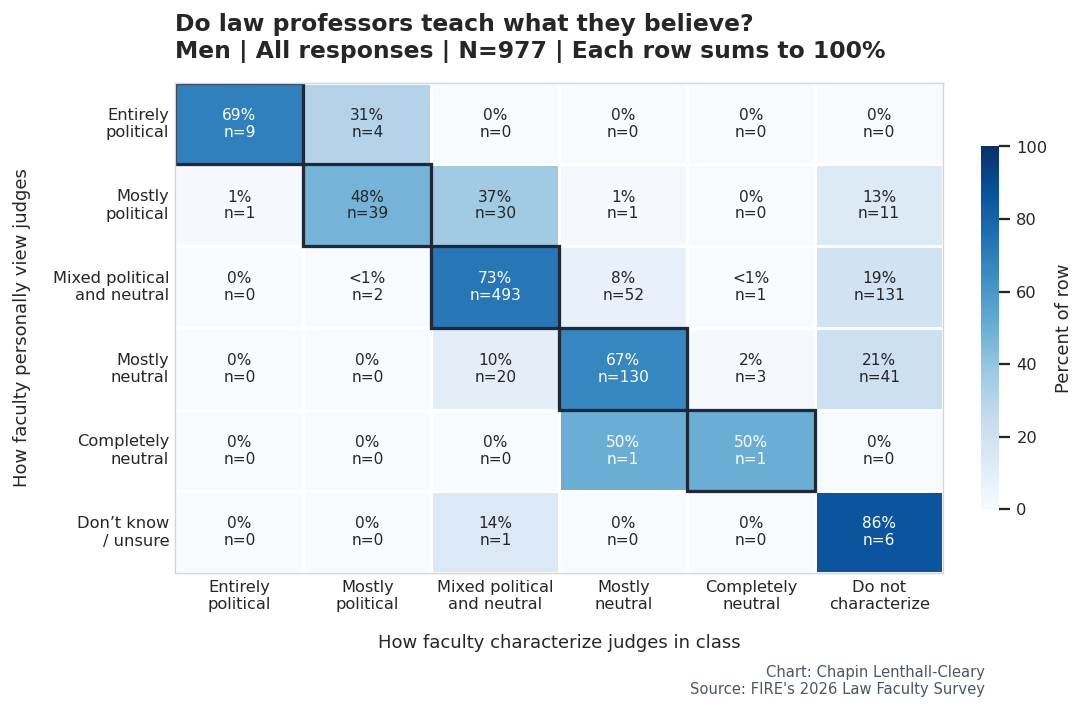

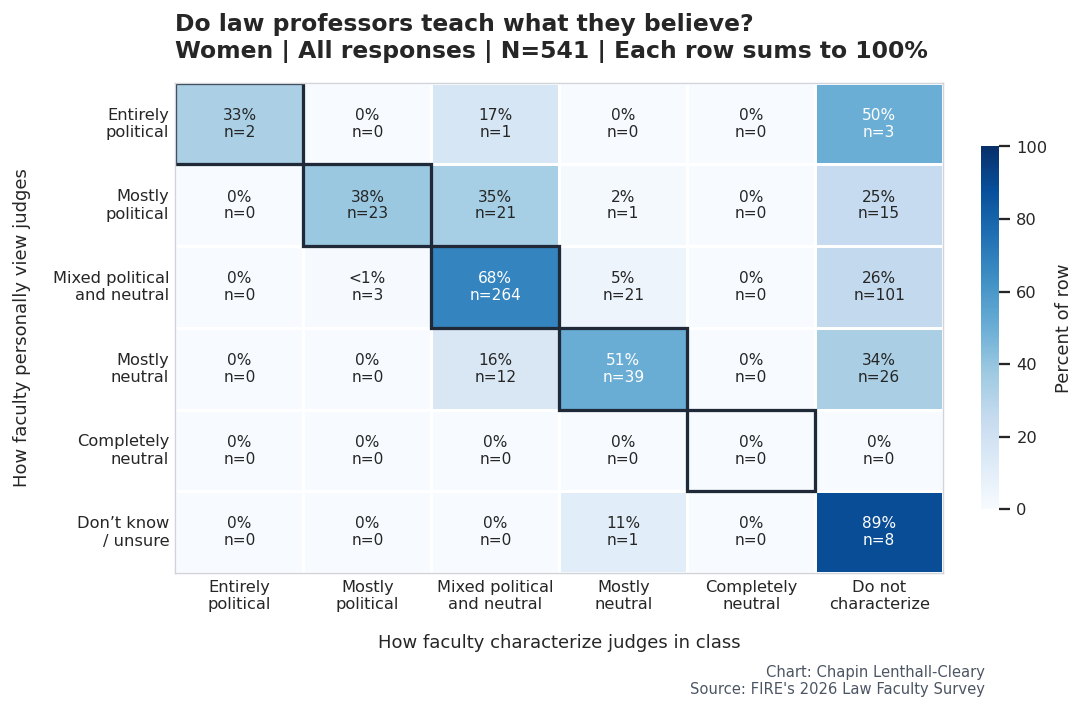

In [7]:
for group in ["Overall", "Male", "Female"]:
    plot_judges_heatmap(heatmap_cells, group, "all_responses")


## Spectrum-only core heatmaps

Excludes answers outside the politically motivated-to-politically neutral scale from both variables, then recalculates row percentages.


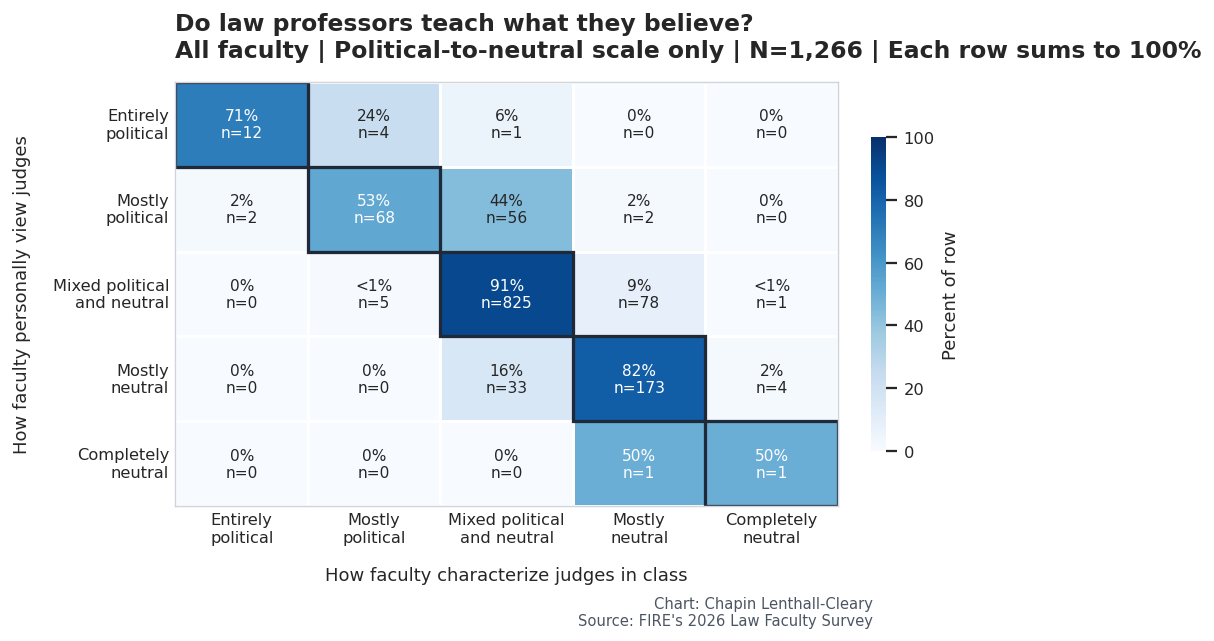

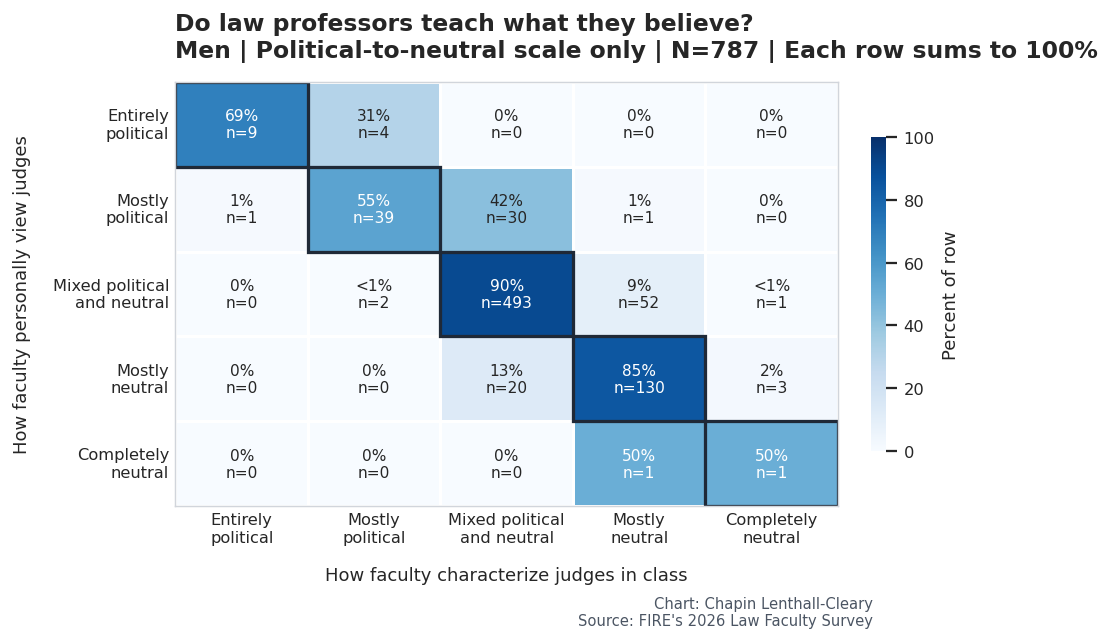

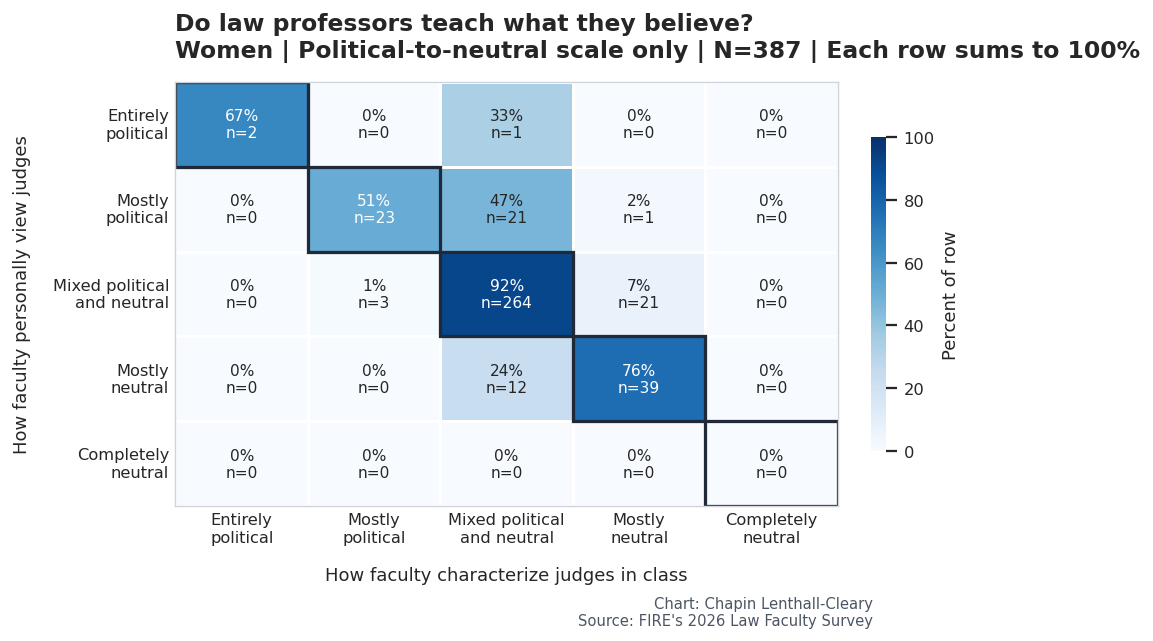

In [8]:
for group in ["Overall", "Male", "Female"]:
    plot_judges_heatmap(heatmap_cells, group, "spectrum_only")
